📥 FASE LOAD DATASET (SEMENTARA)
✅ Data UCI berhasil dimuat! Dimensi data: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



📊 1. VISUALISASI DISTRIBUSI KELAS TARGET


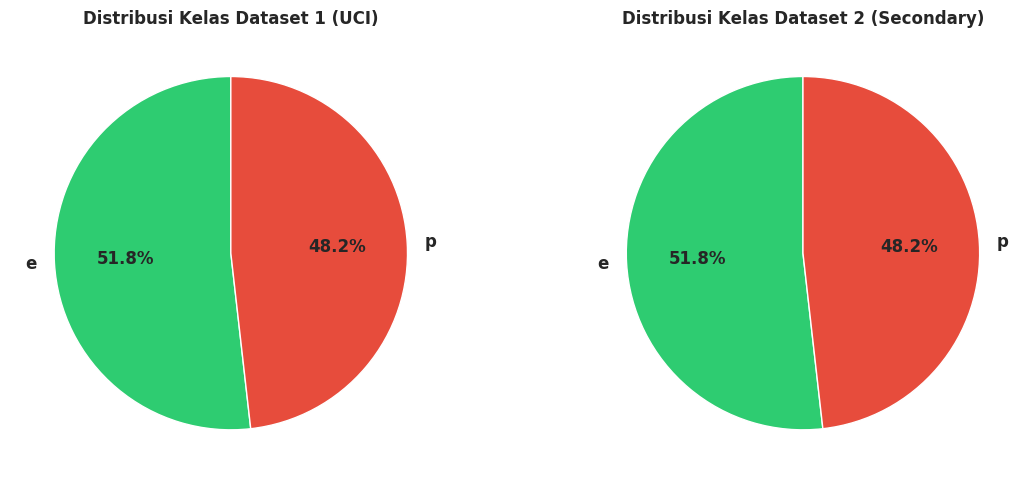

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🍄 2. VISUALISASI FITUR 'ODOR' (BAU) VS KELAS


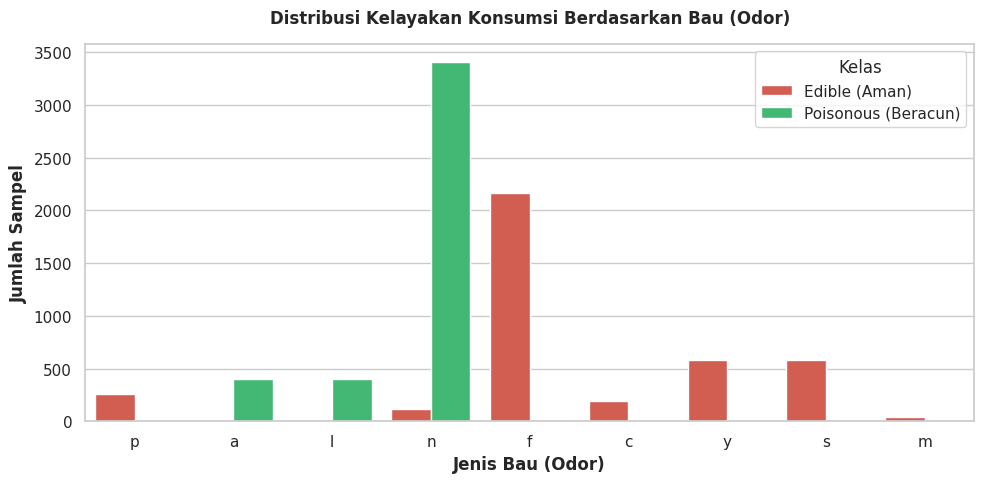

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎨 3. VISUALISASI FITUR FISIK: WARNA INSANG (GILL-COLOR)


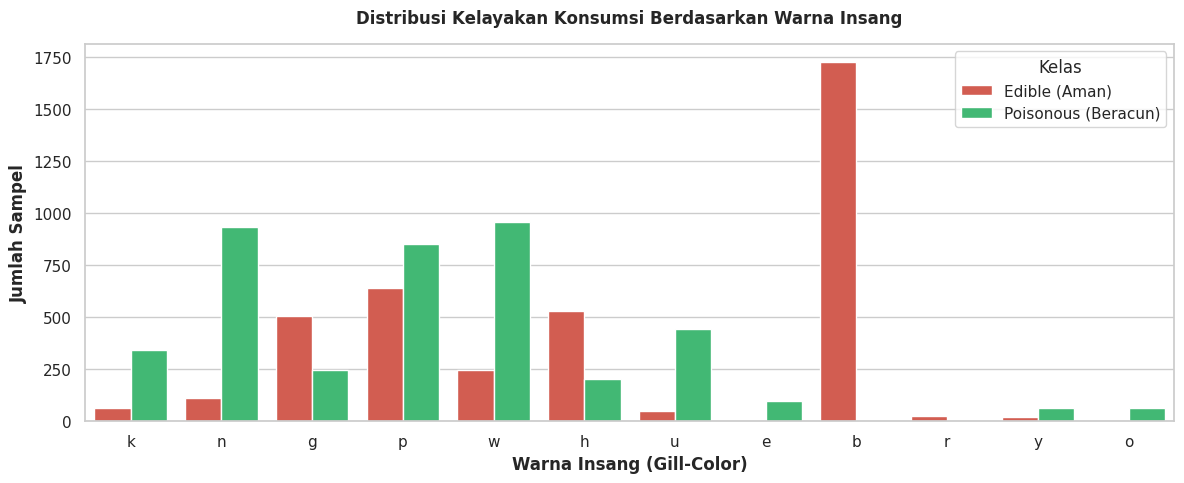

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🔥 4. HEATMAP KORELASI ANTAR CIRI MORFOLOGI


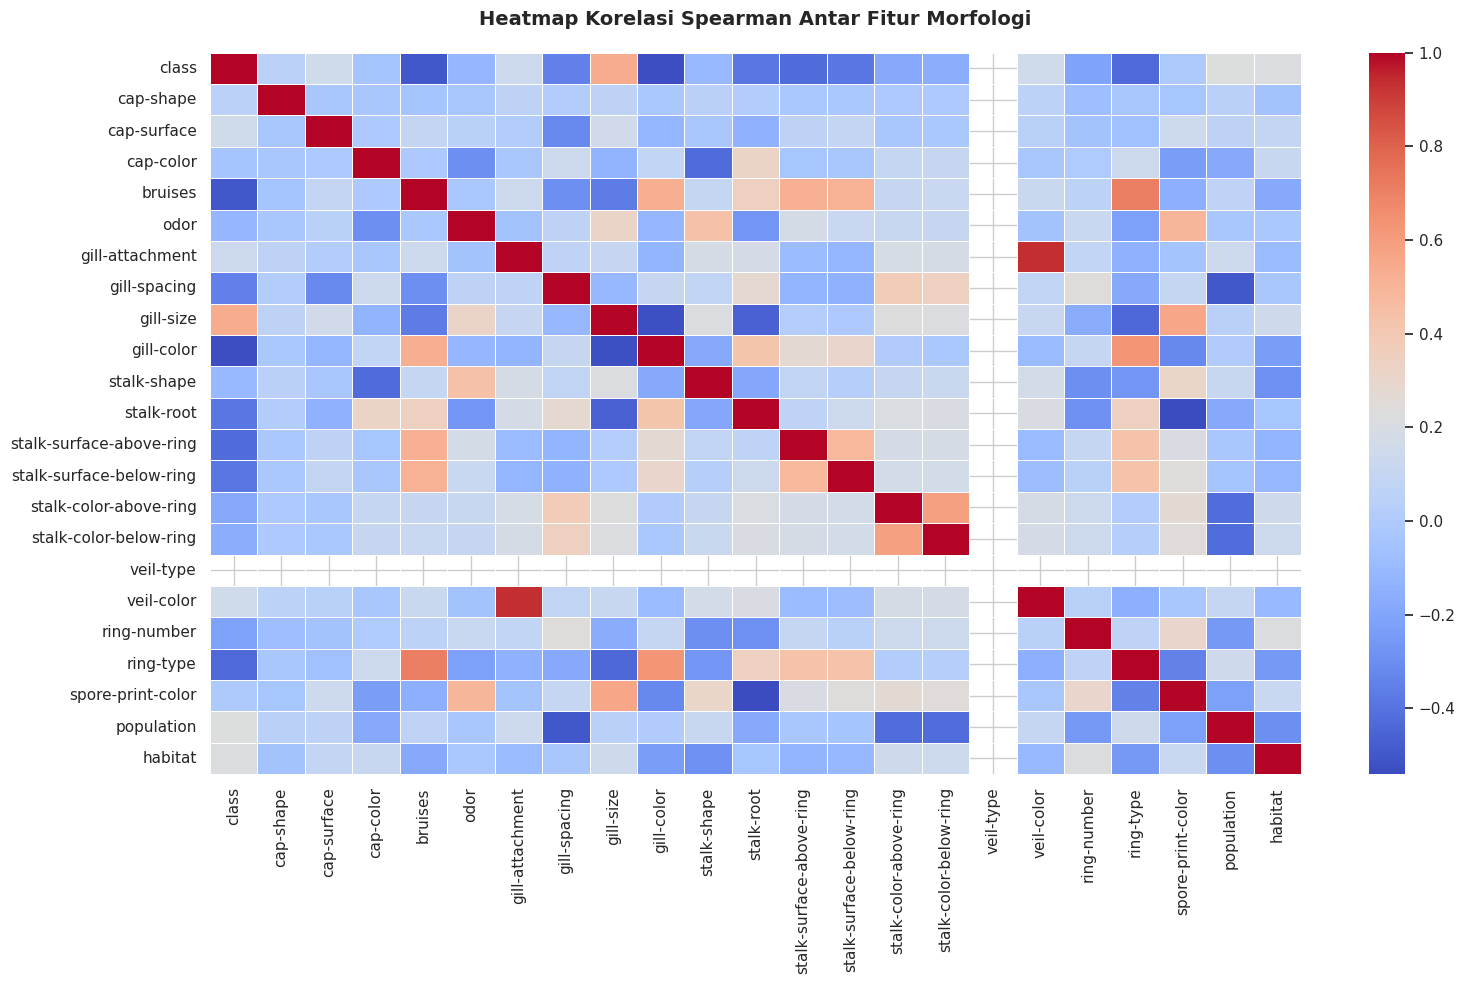

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏆 5. PERINGKAT FITUR PALING PREDIKTIF (CHI-SQUARE)


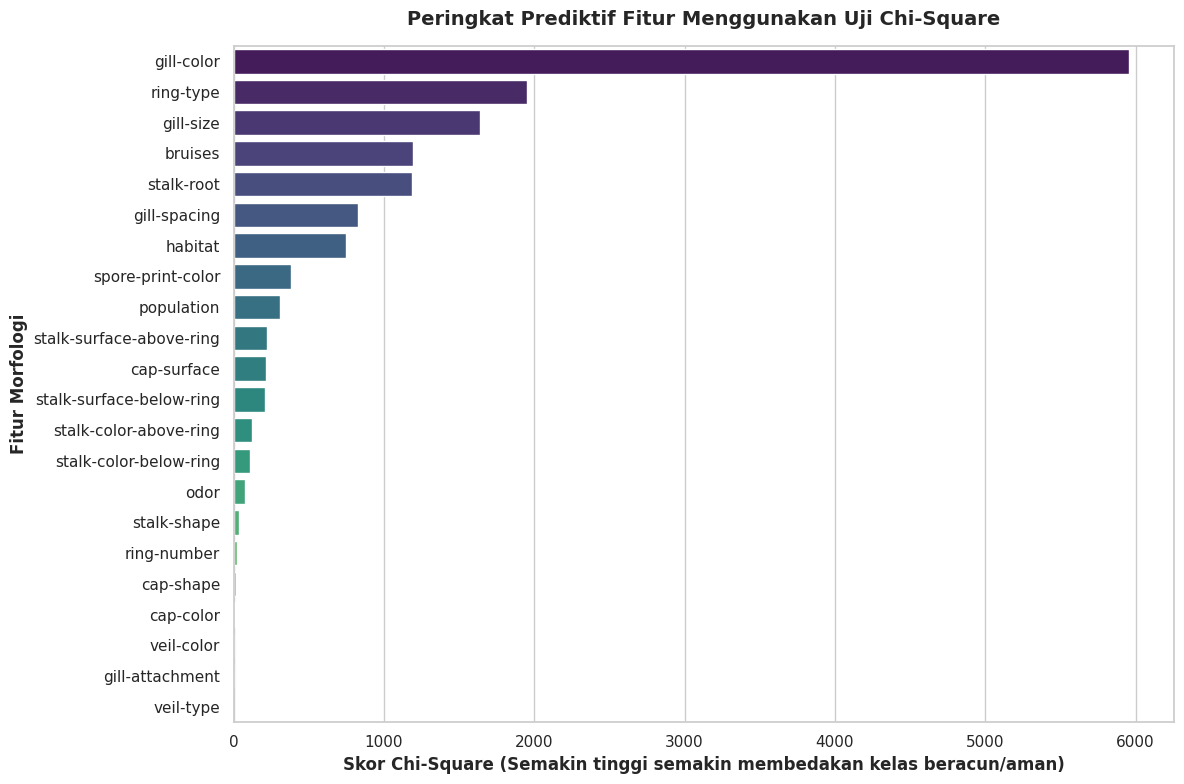

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✨ PROSES EDA SELESAI & FILE BERHASIL DIUNDUH ✨


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
from google.colab import files # Modul khusus Colab untuk download file

print("="*60)
print("📥 FASE LOAD DATASET (SEMENTARA)")
print("="*60)

# 1. Load UCI Mushroom Dataset dari repository public
url_uci = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mushrooms.csv"
df_uci = pd.read_csv(url_uci)

# 2. Duplikat dulu untuk dataset kedua agar kode tidak error
df_sec = df_uci.copy()

print(f"✅ Data UCI berhasil dimuat! Dimensi data: {df_uci.shape}")
display(df_uci.head())

# Setup gaya visualisasi global
sns.set_theme(style="whitegrid")
warna_kelas = {"e": "#2ecc71", "p": "#e74c3c"}


print("\n" + "="*60)
print("📊 1. VISUALISASI DISTRIBUSI KELAS TARGET")
print("="*60)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_uci['class'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Distribusi Kelas Dataset 1 (UCI)', fontweight='bold')
plt.ylabel('')

plt.subplot(1, 2, 2)
df_sec['class'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Distribusi Kelas Dataset 2 (Secondary)', fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.savefig('1_Distribusi_Kelas.png', dpi=300, bbox_inches='tight') # Simpan gambar resolusi tinggi
plt.show()
files.download('1_Distribusi_Kelas.png') # Download otomatis


print("\n" + "="*60)
print("🍄 2. VISUALISASI FITUR 'ODOR' (BAU) VS KELAS")
print("="*60)
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_uci, x='odor', hue='class', palette=warna_kelas)
plt.title('Distribusi Kelayakan Konsumsi Berdasarkan Bau (Odor)', fontweight='bold', pad=15)
plt.xlabel('Jenis Bau (Odor)', fontweight='bold')
plt.ylabel('Jumlah Sampel', fontweight='bold')
plt.legend(title='Kelas', labels=['Edible (Aman)', 'Poisonous (Beracun)'])
plt.tight_layout()
plt.savefig('2_Distribusi_Odor.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('2_Distribusi_Odor.png')


print("\n" + "="*60)
print("🎨 3. VISUALISASI FITUR FISIK: WARNA INSANG (GILL-COLOR)")
print("="*60)
plt.figure(figsize=(12, 5))
sns.countplot(data=df_uci, x='gill-color', hue='class', palette=warna_kelas)
plt.title('Distribusi Kelayakan Konsumsi Berdasarkan Warna Insang', fontweight='bold', pad=15)
plt.xlabel('Warna Insang (Gill-Color)', fontweight='bold')
plt.ylabel('Jumlah Sampel', fontweight='bold')
plt.legend(title='Kelas', labels=['Edible (Aman)', 'Poisonous (Beracun)'])
plt.tight_layout()
plt.savefig('3_Distribusi_GillColor.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('3_Distribusi_GillColor.png')


print("\n" + "="*60)
print("🔥 4. HEATMAP KORELASI ANTAR CIRI MORFOLOGI")
print("="*60)
df_encoded = df_uci.apply(LabelEncoder().fit_transform)

plt.figure(figsize=(16, 10))
correlation_matrix = df_encoded.corr(method='spearman')
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Spearman Antar Fitur Morfologi', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('4_Heatmap_Korelasi.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('4_Heatmap_Korelasi.png')


print("\n" + "="*60)
print("🏆 5. PERINGKAT FITUR PALING PREDIKTIF (CHI-SQUARE)")
print("="*60)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X, y)
chi_scores = pd.Series(chi2_selector.scores_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=chi_scores.values, y=chi_scores.index, hue=chi_scores.index, palette='viridis', legend=False)
plt.title('Peringkat Prediktif Fitur Menggunakan Uji Chi-Square', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Skor Chi-Square (Semakin tinggi semakin membedakan kelas beracun/aman)', fontweight='bold')
plt.ylabel('Fitur Morfologi', fontweight='bold')
plt.tight_layout()
plt.savefig('5_Ranking_Fitur_ChiSquare.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('5_Ranking_Fitur_ChiSquare.png')

print("\n" + "="*60)
print("✨ PROSES EDA SELESAI & FILE BERHASIL DIUNDUH ✨")
print("="*60)